# WEEK 2: Resampling and Cross Validation

| Key              | Value                                                                                                                                                                                                                                                                                                            |
|:-----------------|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Week01** | Resampling and Cross Validation                                                                                                                                                                                                                                                                                            |
| **Course Names** | Machine Learning and Data Science.                                                                                                                                                                                               |
| **Submission Deadline**     | September 30, 2026, 11:45 PM                                                                                                                                                                                                                                                                                          |
| **Student Name & Number**     | Edward Chisaka - 1774058                                                                                                                                                                                                                                                                                                    |
| **Contact**      | edward.chisaka@stud.hslu.ch                                                                                                                                                                                                                                                                                           |
| **Note**         | The link directs to the specific GitHub file for this _Week02_ Lab implementation exercise.<br/> **_Resampling and Cross Validation_**.<br/> _The goal is to understand how the sampling distribution of the sample mean changes with sample size and practice sampling in Python_. <br/> GitHub citation: [BibTeX](https://github.com/CH-CHISAKA/Machine_Learning_and_Data_Science/tree/main/04-assignments/02-assignment) |

# 01: Importing Libraries 

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

# 02: Sampling

* What happens to the sample mean when the sample size gets bigger.

**Key Information** 
- Population: Exponential distribution with λ = 1
- Population mean: μ = 1
- Sample sizes n = 5, 10, 50, 100
- Number of repetitions, N = 10,000

Sample Size | Mean of Sample (Empirical) Means  | Std Dev of Sample (Empirical) Means
--------------------------------------------------------------------------------
5               | 0.9999               | 0.4450              
10              | 0.9910               | 0.3163              
50              | 0.9983               | 0.1414              
100             | 1.0000               | 0.1005              


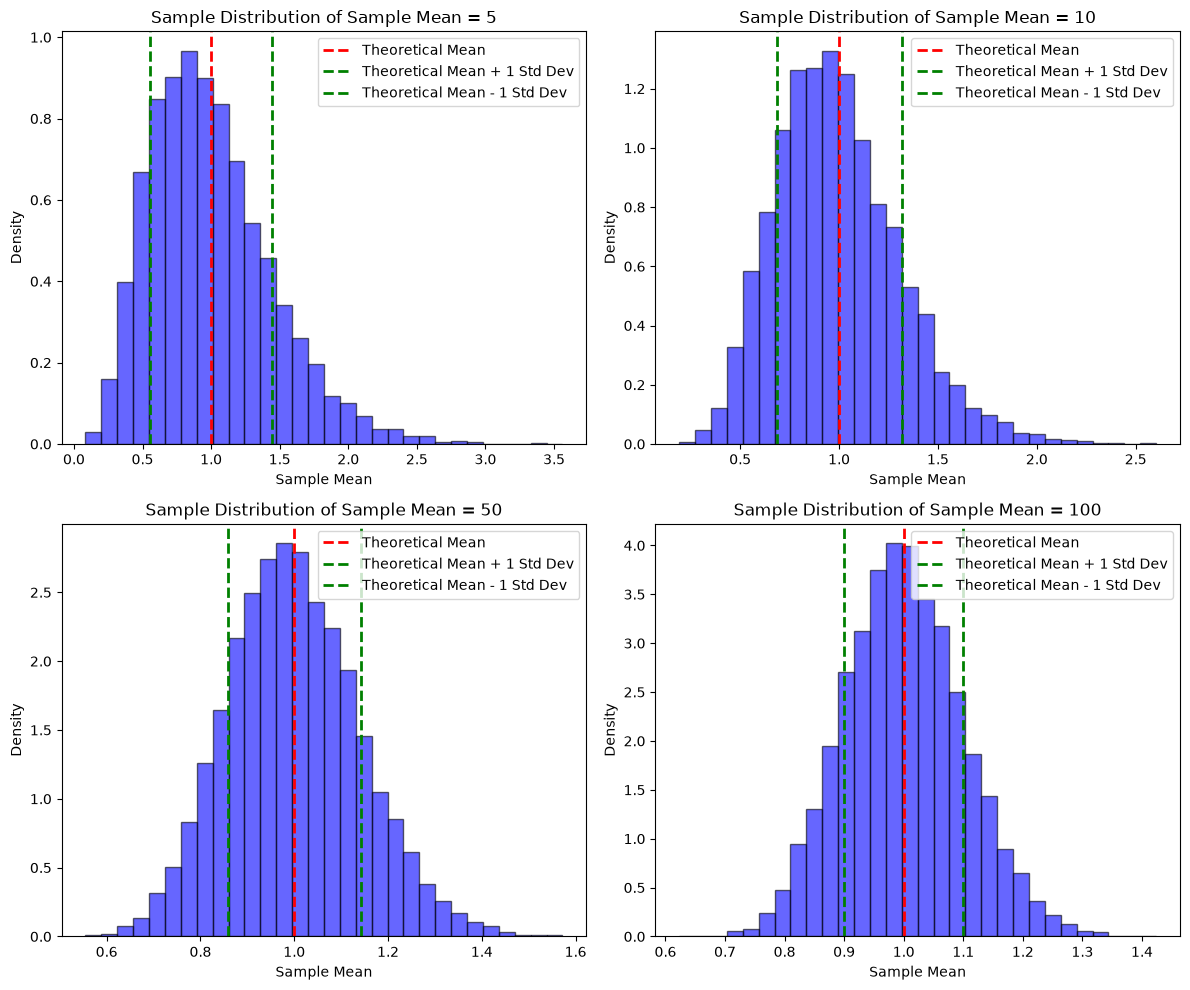

In [9]:
def simulate_means(sample_size = (5, 10, 50, 100), num_simulations=10000, seed=1):
    # Random number generation
    rng = np.random.default_rng(seed)
    
    results = {}
    
    for size in sample_size:
        
        # Exponential distribution with mean (lambda λ) = 1
        samples = rng.exponential(scale=1.0, size=(num_simulations, size))
        
        # Calculate the sample mean for each simulation (10,000 simulations)
        sample_means = samples.mean(axis=1)
        
        # Storing the results in a dictionary
        results[size] = sample_means
        
    return results

# Simulation
results = simulate_means(
    sample_size=(5, 10, 50, 100), 
    num_simulations=10000, 
    seed=1
)

# Tabulate the results
print ("Sample Size | Mean of Sample (Empirical) Means  | Std Dev of Sample (Empirical) Means")
print("-"*80)

for size, sample_means in results.items():
    empirical_mean = sample_means.mean()
    empirical_std = sample_means.std(ddof=1)  # Sample standard deviation
    
    print(f"{size:<15d} | {empirical_mean:<20.4f} | {empirical_std:<20.4f}")
    
# Plotting the results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (size, sample_means) in zip(axes.flatten(), results.items()):
    ax.hist(sample_means, bins=30, density=True, alpha=0.6, color='b', edgecolor='black')
    
    # Theoretical mean and standard deviation for the exponential distribution
    theoretical_mean = 1.0  # Mean of exponential distribution with λ=1
    theoretical_std = 1.0 / np.sqrt(size)  # Standard deviation of the sample mean
    
    ax.axvline(theoretical_mean, color='r', linestyle='dashed', linewidth=2, label='Theoretical Mean')
    ax.axvline(theoretical_mean + theoretical_std, color='g', linestyle='dashed', linewidth=2, label='Theoretical Mean + 1 Std Dev')
    ax.axvline(theoretical_mean - theoretical_std, color='g', linestyle='dashed', linewidth=2, label='Theoretical Mean - 1 Std Dev')
    
    ax.set_title(f'Sample Distribution of Sample Mean = {size}')
    ax.set_xlabel('Sample Mean')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()
